In [268]:
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import numpy as np
import random

from new_dataset import DunexDataset
from network import ResNetUNet
import torch
from visualize_dataset import plot_dataset_grid
from loss import calc_loss

%load_ext autoreload
%autoreload 2

plt.rcParams['image.origin'] = 'lower'  # Set default origin to lower


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [269]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model = ResNetUNet(n_class=1)
model = model.to(device)


In [270]:
image_copies = 3
samples_per_image = 32
ds = DunexDataset('cvat_annotations/triplets_fully_labeled/images', 'cvat_annotations/triplets_fully_labeled/annotations_poly.xml', samples_per_image = image_copies * samples_per_image)
train, val, test = torch.utils.data.random_split(ds, (100 * samples_per_image, 40 * samples_per_image, 7 * samples_per_image)) # 147 (* 3) * 32
batch_size = 64

# Should be deterministic, might need to change to add more workers 
dataloaders = {
    'train': DataLoader(train, batch_size=batch_size, shuffle=True, num_workers=0),
    'val':   DataLoader(val,   batch_size=batch_size, shuffle=True, num_workers=0),
    'test':  DataLoader(test,  batch_size=batch_size, shuffle=True, num_workers=0),
}


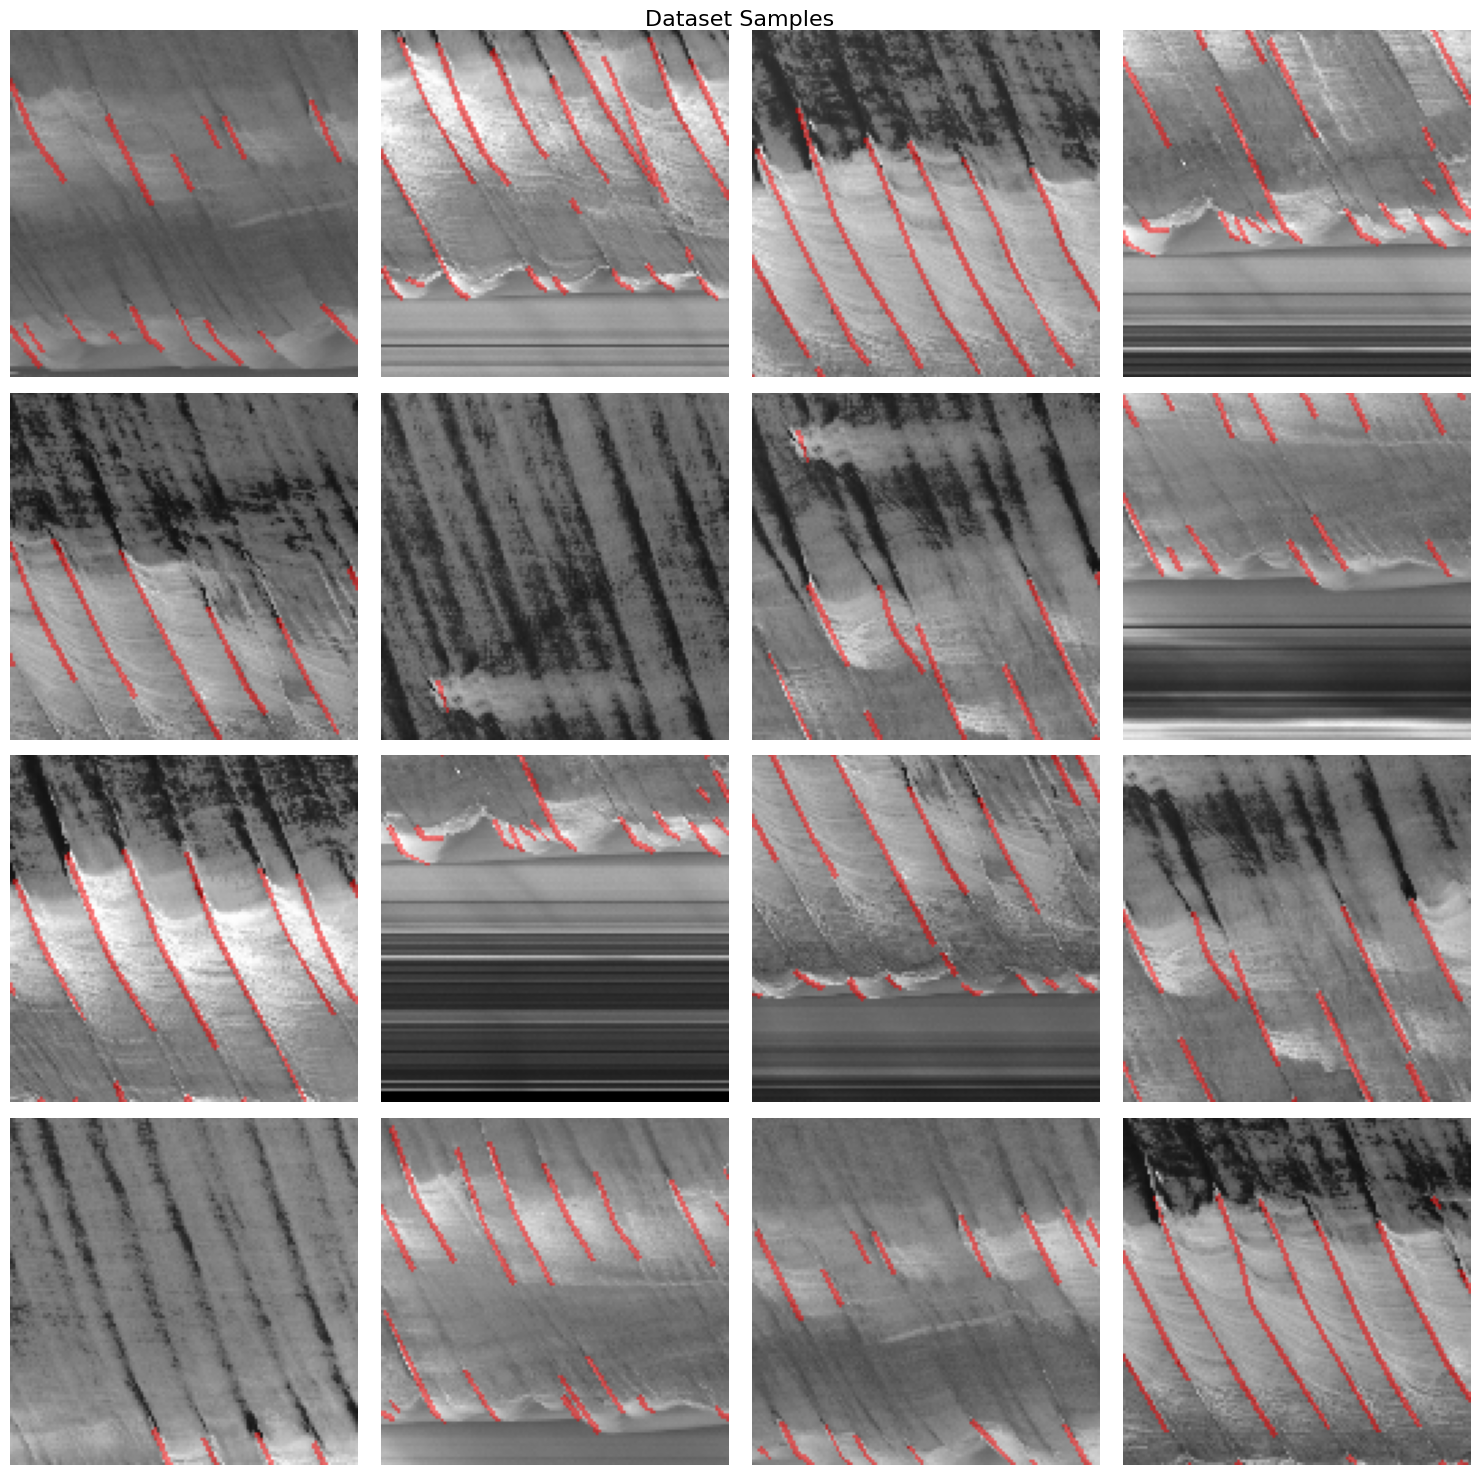

In [247]:
plot_dataset_grid(dataloaders['val'].dataset)

In [253]:
from collections import defaultdict
import torch.nn.functional as F
# from loss import dice_loss

import torch
import torch.optim as optim
from torch.optim import lr_scheduler
import time
import copy
from tqdm import tqdm

def print_metrics(metrics, epoch_samples, phase):
    outputs = []
    for k in metrics.keys():
        outputs.append("{}: {:4f}".format(k, metrics[k] / epoch_samples))

    print("{}: {}".format(phase, ", ".join(outputs)))

def train_model(model, optimizer, scheduler, num_epochs=25):
    l = []
    validation_metrics = defaultdict(list)
    train_metrics = defaultdict(list)
    best_model_wts = copy.deepcopy(model.state_dict())
    best_loss = 1e10

    for epoch in range(num_epochs):
        print('Epoch {}/{}'.format(epoch, num_epochs - 1))
        print('-' * 10)

        since = time.time()

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                for param_group in optimizer.param_groups:
                    print("LR", param_group['lr'])

                model.train()  # Set model to training mode
            else:
                model.eval()   # Set model to evaluate mode

            metrics = defaultdict(float)
            epoch_samples = 0

            for inputs, labels in (dataloaders[phase]):
                inputs = inputs.to(device)
                labels = labels.to(device)
                
                # zero the parameter gradients
                optimizer.zero_grad()

                # forward
                # track history if only in train
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                
                    loss = calc_loss(outputs, labels, metrics, epoch, start_boundary_epoch=25)


                    # backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()
                        scheduler.step()
                        
                    
                # statistics
                epoch_samples += inputs.size(0)
            
            if phase == 'train':
                train_metrics['boundary_loss'].append(metrics['boundary']/epoch_samples)
                train_metrics['focal'].append(metrics['focal']/epoch_samples)
                train_metrics['dice'].append(metrics['dice']/epoch_samples)
                train_metrics['disc'].append(metrics['disc']/epoch_samples)
                train_metrics['loss'].append(loss.detach().cpu())
                
            if phase == 'val':
                validation_metrics['boundary_loss'].append(metrics['boundary']/epoch_samples)
                validation_metrics['focal'].append(metrics['focal']/epoch_samples)
                validation_metrics['dice'].append(metrics['dice']/epoch_samples)
                validation_metrics['disc'].append(metrics['disc']/epoch_samples)
                validation_metrics['loss'].append(loss.detach().cpu())


            print_metrics(metrics, epoch_samples, phase)
            epoch_loss = metrics['loss'] / epoch_samples
            
            # deep copy the model
            if phase == 'val' and epoch_loss < best_loss:
                print("saving best model")
                best_loss = epoch_loss
                best_model_wts = copy.deepcopy(model.state_dict())

        if phase == 'val':
            l.append(epoch_loss)

        time_elapsed = time.time() - since
        print('{:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))

    print('Best val loss: {:4f}'.format(best_loss))


    # load best model weights
    model.load_state_dict(best_model_wts)
    return model, l, train_metrics, validation_metrics

Epoch 0/299
----------
LR 0.0005
train: focal: 0.031978, dice: 0.744221, loss: 0.388099, boundary: 0.000000, disc: 0.000000
val: focal: 0.125006, dice: 0.632771, loss: 0.378889, boundary: 0.000000, disc: 0.000000
saving best model
0m 48s
Epoch 1/299
----------
LR 0.000575025008336112
train: focal: 0.046981, dice: 0.469331, loss: 0.258156, boundary: 0.000000, disc: 0.000000
val: focal: 0.040461, dice: 0.431957, loss: 0.236209, boundary: 0.000000, disc: 0.000000
saving best model
0m 48s
Epoch 2/299
----------
LR 0.0006500500166722241
train: focal: 0.042955, dice: 0.387015, loss: 0.214985, boundary: 0.000000, disc: 0.000000
val: focal: 0.043361, dice: 0.370527, loss: 0.206944, boundary: 0.000000, disc: 0.000000
saving best model
0m 48s
Epoch 3/299
----------
LR 0.0007250750250083362
train: focal: 0.039078, dice: 0.337038, loss: 0.188058, boundary: 0.000000, disc: 0.000000
val: focal: 0.043615, dice: 0.346151, loss: 0.194883, boundary: 0.000000, disc: 0.000000
saving best model
0m 49s
Epoc

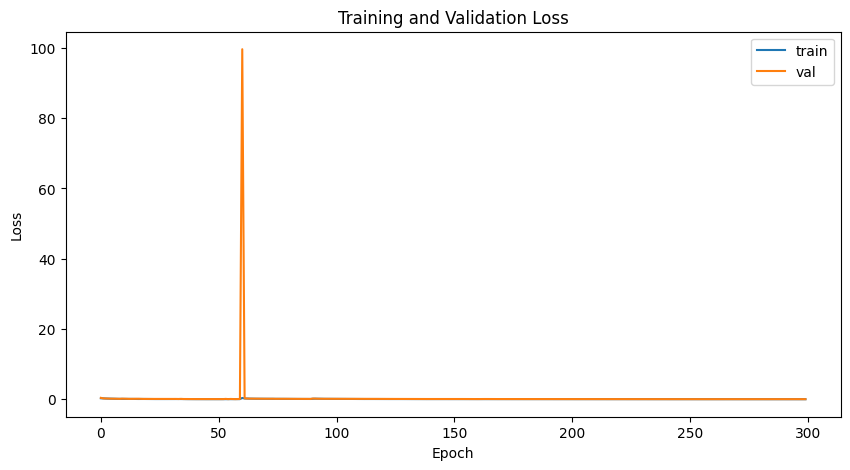

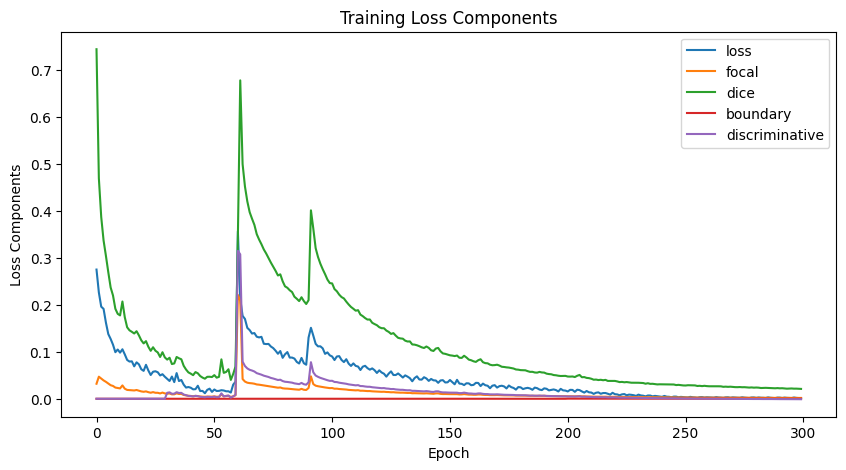

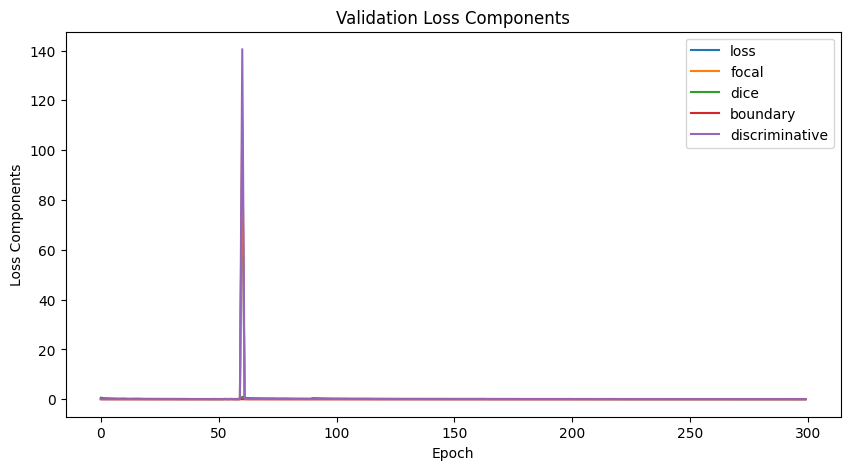

In [249]:
from loss import *

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

num_class = 1
model = ResNetUNet(num_class).to(device)



optimizer_ft = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-2)


epochs = 50

from torch.optim.lr_scheduler import OneCycleLR
scheduler = OneCycleLR(optimizer_ft, 
                       max_lr=5e-3,  # Increased from 1e-3
                       epochs=epochs,    # Train longer
                       steps_per_epoch=len(dataloaders['train']),
                       div_factor=10, # Smaller div_factor for higher starting LR
                       final_div_factor=1e2, # Less aggressive final LR reduction
                       pct_start=0.2,  # Shorter warmup
                       anneal_strategy='linear') # Linear annealing


model, loss, train_metrics, val_metrics= train_model(model, optimizer_ft, scheduler, num_epochs=epochs)
import datetime
torch.save(model.state_dict(), f'best_model_{datetime.date.today().strftime('%Y%m%d')}.pt')

plt.figure(figsize=(10, 5))
plt.plot(train_metrics['loss'], label='train')
plt.plot(val_metrics['loss'], label='val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.figure(figsize=(10, 5))
plt.plot(train_metrics['loss'], label='loss')
plt.plot(train_metrics['focal'], label='focal')
plt.plot(train_metrics['dice'], label='dice')
plt.plot(train_metrics['boundary_loss'], label='boundary')
plt.plot(train_metrics['disc'], label='discriminative')
plt.xlabel('Epoch')
plt.ylabel('Loss Components')
plt.title('Training Loss Components')
plt.legend()

plt.figure(figsize=(10, 5))
plt.plot(val_metrics['loss'], label='loss')
plt.plot(val_metrics['focal'], label='focal')
plt.plot(val_metrics['dice'], label='dice')
plt.plot(val_metrics['boundary_loss'], label='boundary')
plt.plot(val_metrics['disc'], label='discriminative')
plt.xlabel('Epoch')
plt.ylabel('Loss Components')
plt.title('Validation Loss Components')
plt.legend()

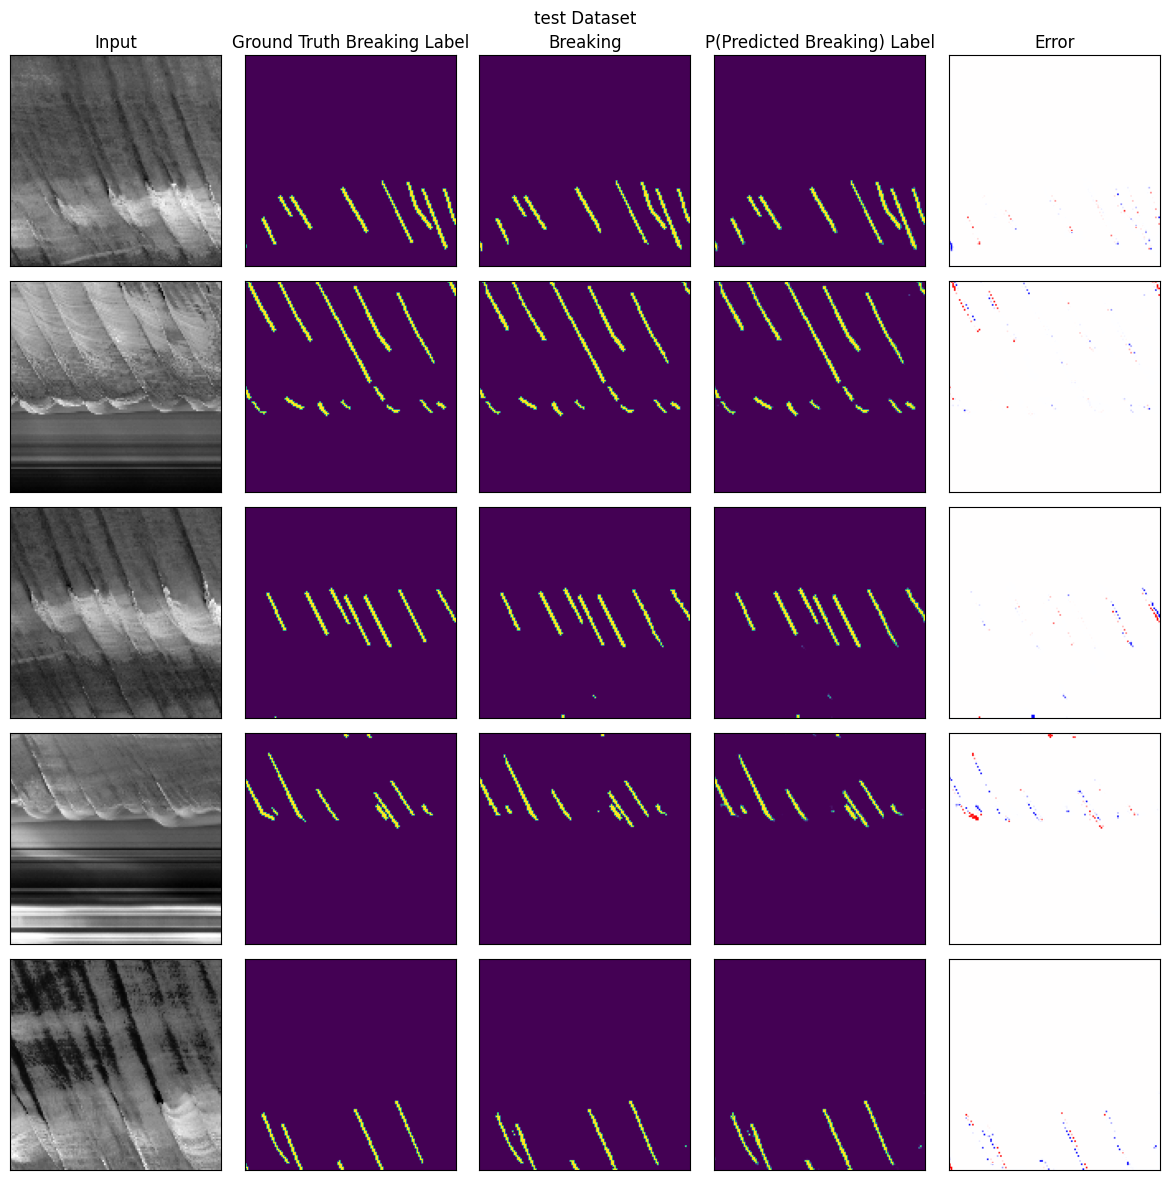

In [254]:
fig, axs = plt.subplots(5, 5, figsize=(12, 12))
plt.subplots_adjust(hspace=0.3)  # Add space between rows
d='test'
# Get predictions for multiple examples
for idx in range(5):
    img, mask = dataloaders[d].dataset[idx]
    pred = F.sigmoid(model(img.unsqueeze(0).to(device))).cpu().detach().numpy()
    
    # Plot images for this example
    axs[idx, 0].imshow(img[0], cmap='gray')
    axs[idx, 1].imshow(mask[0])
    im = axs[idx, 2].imshow(pred.squeeze()>0.5, cmap='viridis', vmax=1, vmin=0)
    im = axs[idx, 3].imshow(pred.squeeze(), cmap='viridis', vmax=1, vmin=0)
    diff = axs[idx, 4].imshow(mask[0] - pred.squeeze(), cmap='bwr', vmin=-1, vmax=1)
    
    # Make all plots have same aspect ratio and remove ticks
    for ax in axs[idx]:
        ax.set_aspect('equal')
        ax.set_xticks([])
        ax.set_yticks([])
        
    # Add row titles only to the first column
    if idx == 0:
        axs[idx, 0].set_title("Input")
        axs[idx, 1].set_title('Ground Truth Breaking Label')
        axs[idx, 2].set_title('Breaking')
        axs[idx, 3].set_title('P(Predicted Breaking) Label')
        axs[idx, 4].set_title('Error')
# Add colorbars for prediction and error
# for idx in range(4):
#     # Colorbar for prediction
#     pos = axs[idx, 2].get_position()
#     cb_ax = fig.add_axes([pos.x1 + 0.01, pos.y0, 0.01, pos.height])
#     plt.colorbar(im, cax=cb_ax)
    
#     # Colorbar for error
#     pos = axs[idx, 3].get_position()
#     cb_ax = fig.add_axes([pos.x1 + 0.01, pos.y0, 0.01, pos.height])
#     plt.colorbar(diff, cax=cb_ax)
fig.suptitle(f'{d} Dataset')
plt.tight_layout()
plt.show()


In [252]:
torch.save(model.state_dict(), 'best_model_20241119.pt')


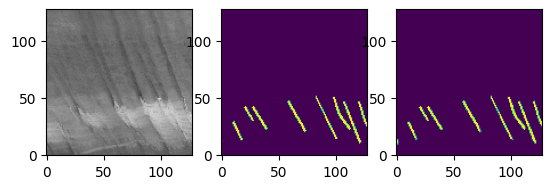

In [266]:
from predict import *
img, mask = dataloaders['test'].dataset[0]
model.eval().to('cpu')
pred = predict_patch(model, img)

fig, axs = plt.subplots(1, 3)
axs[0].imshow(img.permute(1, 2, 0))
axs[1].imshow(mask.squeeze())
axs[2].imshow(pred)


In [263]:
torch.transpose(img, )

tensor([[[0.3725, 0.3608, 0.3333,  ..., 0.3608, 0.3765, 0.3216],
         [0.3412, 0.3725, 0.4118,  ..., 0.3569, 0.3843, 0.3608],
         [0.3686, 0.3765, 0.4039,  ..., 0.3961, 0.3725, 0.3569],
         ...,
         [0.4392, 0.4314, 0.4196,  ..., 0.5176, 0.4863, 0.4941],
         [0.4353, 0.4235, 0.4275,  ..., 0.4471, 0.4667, 0.4824],
         [0.4353, 0.4078, 0.3961,  ..., 0.4667, 0.4627, 0.4784]],

        [[0.3725, 0.3608, 0.3333,  ..., 0.3608, 0.3765, 0.3216],
         [0.3412, 0.3725, 0.4118,  ..., 0.3569, 0.3843, 0.3608],
         [0.3686, 0.3765, 0.4039,  ..., 0.3961, 0.3725, 0.3569],
         ...,
         [0.4392, 0.4314, 0.4196,  ..., 0.5176, 0.4863, 0.4941],
         [0.4353, 0.4235, 0.4275,  ..., 0.4471, 0.4667, 0.4824],
         [0.4353, 0.4078, 0.3961,  ..., 0.4667, 0.4627, 0.4784]],

        [[0.3725, 0.3608, 0.3333,  ..., 0.3608, 0.3765, 0.3216],
         [0.3412, 0.3725, 0.4118,  ..., 0.3569, 0.3843, 0.3608],
         [0.3686, 0.3765, 0.4039,  ..., 0.3961, 0.3725, 0.